# Step 1 - Exploratory Data Analysis (EDA)
### Career Progression and Promotion Gap Analysis for Retention Optimization
**Palo Alto Networks | Unified Mentor**

**What this notebook does:** Loads the raw HR dataset and looks at it from
every angle *before* we touch machine learning - row/column counts, missing
values, the attrition split, correlations between numeric fields, outliers
in tenure variables, and attrition by department/role.

**Why this matters:** Skipping EDA is the #1 cause of broken downstream
models. If we jumped straight into clustering without first checking for
missing values, class imbalance, or extreme outliers, we could build a
segmentation that *looks* statistically valid but is secretly being
distorted by a handful of bad or unusual records. EDA is our sanity check
before anything else.

**What you'll see:** Every code cell below shows its chart directly
underneath it (no more hunting through a `charts/` folder), plus the
figures are still saved to disk as PNGs in case you want them for a report.

## Setup
**What:** Import the libraries we need and turn on inline chart display.
**Why:** `%matplotlib inline` tells Jupyter to render every chart directly
below the cell that created it, instead of opening a separate window (which
doesn't work in a notebook anyway) or doing nothing at all.

In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

chart_dir = "charts"
os.makedirs(chart_dir, exist_ok=True)

print("Libraries loaded. Charts will display below each cell AND save to the 'charts' folder.")

Libraries loaded. Charts will display below each cell AND save to the 'charts' folder.


## 1. Load the Dataset
**What:** Read the raw HR CSV file into a pandas DataFrame called `df`.
**Why:** Everything in this entire project builds on this single load -
if this cell fails, nothing downstream will work, so we check it carefully.
**Expected result:** ~1,470 rows, ~31 raw columns, 0 missing values,
0 duplicate rows. If you see a `FileNotFoundError`, the CSV isn't in the
same folder as this notebook - check the file name (spaces, not underscores).

In [5]:
df = pd.read_csv("Palo Alto Networks.csv")

print("File successfully loaded!\n")
print("--- Dataset Information ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns Before Engineering: {df.shape[1]}")
print(f"Missing Values (total): {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.head()

File successfully loaded!

--- Dataset Information ---
Total Rows: 1470
Total Columns Before Engineering: 31
Missing Values (total): 0
Duplicate Rows: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2. Attrition Distribution
**What:** Count how many employees stayed (`Attrition = 0`) vs left
(`Attrition = 1`), then plot it two ways: a bar chart (exact counts) and a
donut chart (share at a glance).
**Why:** This single number frames the whole project. It also reveals an
important fact we must design around: the dataset is **imbalanced** - far
more people stay than leave. That's why later on, "Retention Opportunity"
logic doesn't just chase raw attrition; it also looks at promotion-gap risk
for people who *haven't* left yet.
**Expected result:** Roughly 84% stayed, 16% left.

--- Attrition Count ---
Attrition
0    1233
1     237
Name: count, dtype: int64


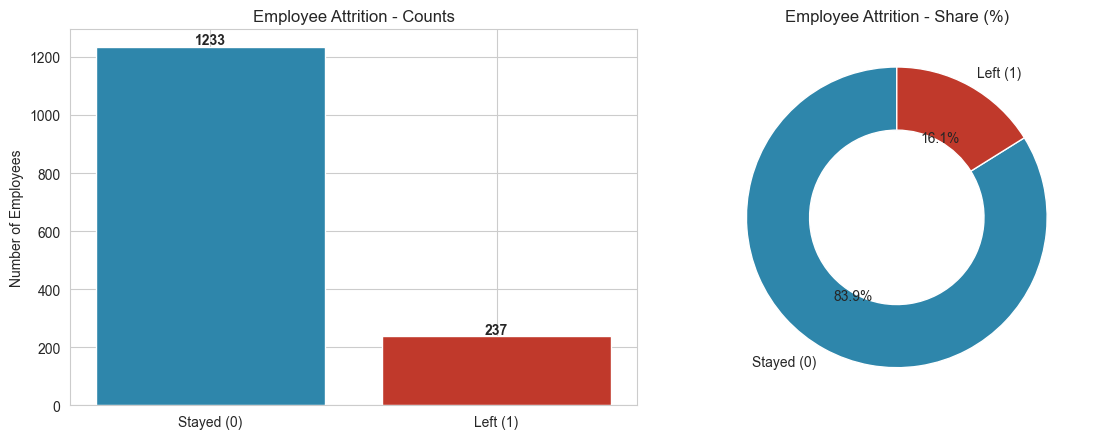

In [6]:
print("--- Attrition Count ---")
print(df["Attrition"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = df["Attrition"].value_counts().sort_index()
axes[0].bar(["Stayed (0)", "Left (1)"], counts.values, color=["#2E86AB", "#C0392B"])
axes[0].set_title("Employee Attrition - Counts")
axes[0].set_ylabel("Number of Employees")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values, labels=["Stayed (0)", "Left (1)"], autopct="%1.1f%%",
    colors=["#2E86AB", "#C0392B"], startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
axes[1].set_title("Employee Attrition - Share (%)")

plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig1_attrition_distribution.png"), dpi=150)
plt.show()

## 3. Correlation Heatmap
**What:** Compute pairwise correlation across every numeric column and
visualise it as a colour-coded heatmap (dark red = strong positive
relationship, dark blue = strong negative relationship).
**Why:** Two reasons: (1) it shows which raw numeric fields relate most to
Attrition, giving context before we engineer new features, and (2) it
flags **multicollinearity** - features that basically duplicate each other
- which we'd want to avoid feeding twice into the same clustering model.
**Expected result:** No single feature will correlate strongly with
Attrition (|r| typically under 0.2). That's the core premise of this whole
project: attrition is driven by a *combination* of structural career
signals, not any one variable acting alone.

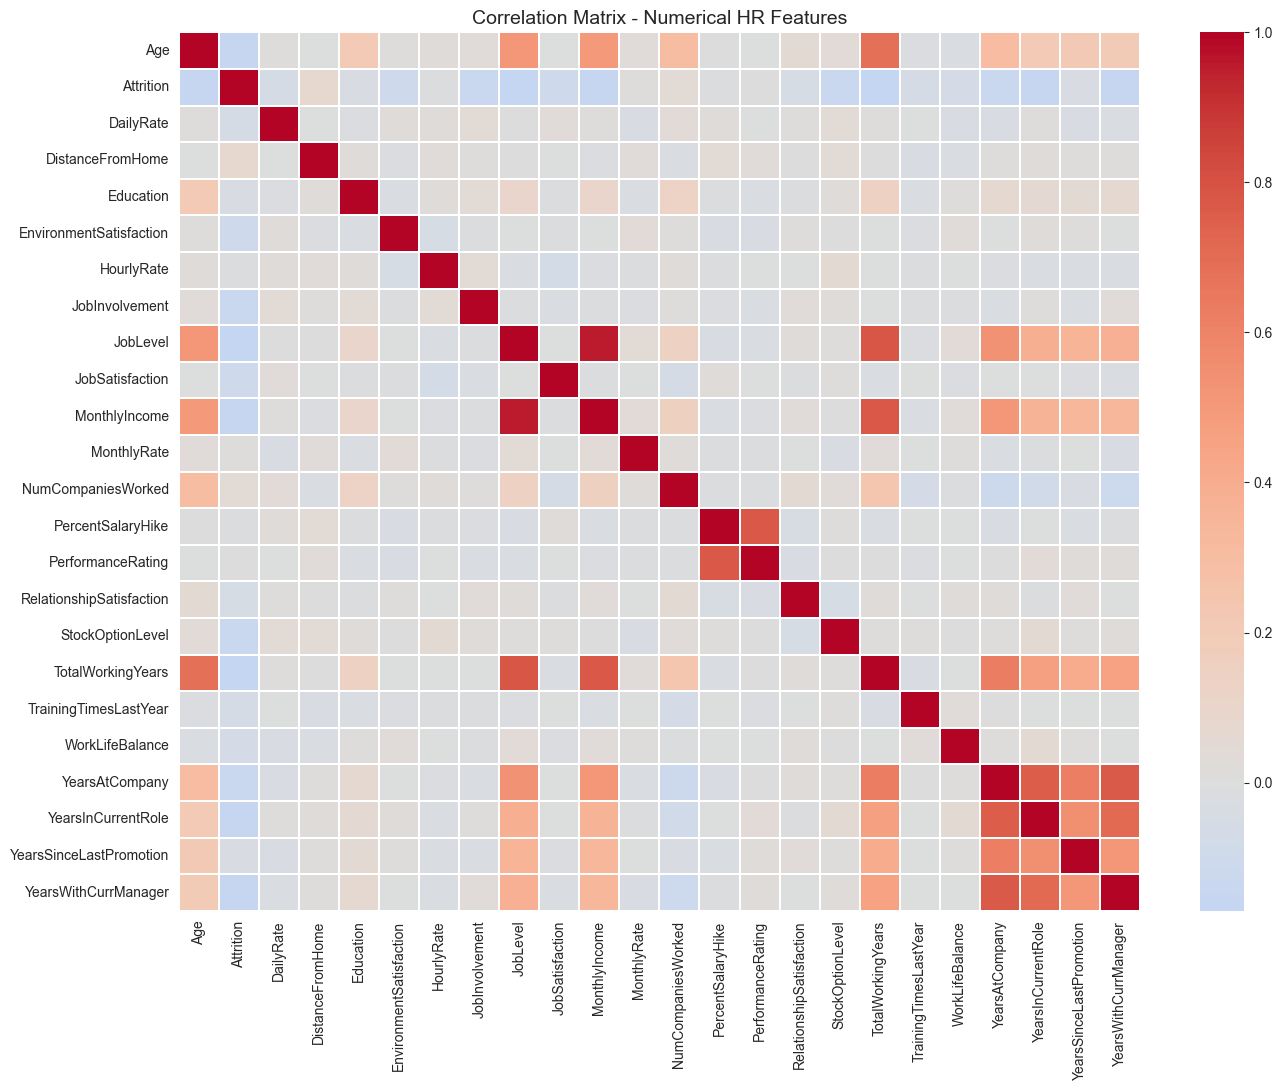

--- Top Numerical Correlates of Attrition ---
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
Name: Attrition, dtype: float64


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Matrix - Numerical HR Features", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig2_correlation_heatmap.png"), dpi=150)
plt.show()

top_corr_with_attrition = corr["Attrition"].drop("Attrition").abs().sort_values(ascending=False).head(8)
print("--- Top Numerical Correlates of Attrition ---")
print(top_corr_with_attrition)

## 4. Career-Tenure Variables: Outlier Screening
**What:** Boxplot the five tenure-related variables that will later feed
our engineered ratios and the clustering model. Points beyond the "whiskers"
of each box are potential outliers.
**Why:** K-Means clustering (used in Step 3) measures straight-line
distance between employees. A handful of extreme long-tenure records could
quietly pull cluster centres toward themselves and distort the grouping for
everyone else. Spotting that risk here justifies removing extreme outliers
later in Step 2.
**Expected result:** Right-skewed distributions - most employees have
short-to-medium tenure, with a long tail of senior employees showing up as
dots above the top whisker.

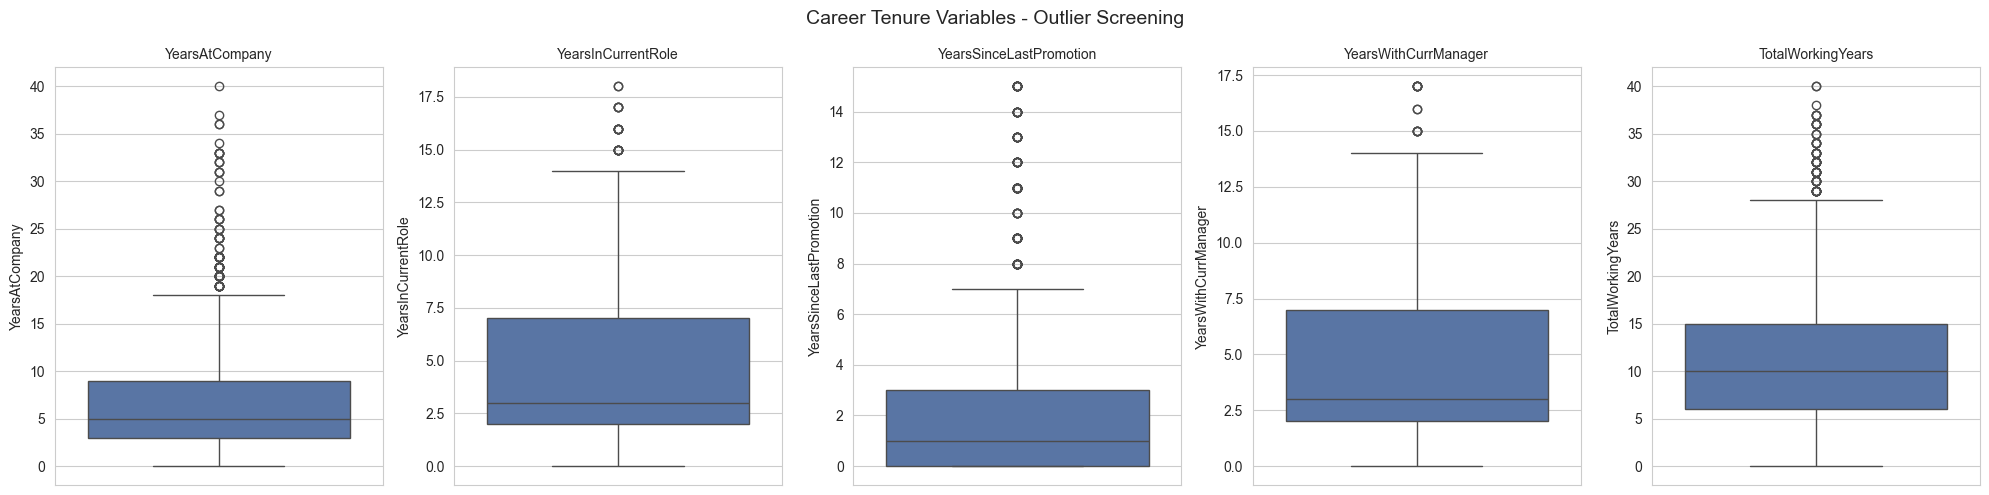

--- Outlier Screening (IQR method) ---
YearsAtCompany              : 104 potential outliers (bounds -6.0 - 18.0)
YearsInCurrentRole          : 21 potential outliers (bounds -5.5 - 14.5)
YearsSinceLastPromotion     : 107 potential outliers (bounds -4.5 - 7.5)
YearsWithCurrManager        : 14 potential outliers (bounds -5.5 - 14.5)
TotalWorkingYears           : 63 potential outliers (bounds -7.5 - 28.5)


In [8]:
stagnation_vars = ["YearsAtCompany", "YearsInCurrentRole",
                    "YearsSinceLastPromotion", "YearsWithCurrManager", "TotalWorkingYears"]

fig, axes = plt.subplots(1, len(stagnation_vars), figsize=(20, 5))
for ax, col in zip(axes, stagnation_vars):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
plt.suptitle("Career Tenure Variables - Outlier Screening", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig3_outlier_boxplots.png"), dpi=150)
plt.show()

print("--- Outlier Screening (IQR method) ---")
for col in stagnation_vars:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:28s}: {n_out} potential outliers (bounds {lower:.1f} - {upper:.1f})")

## 5. Attrition Rate by Department & Job Role
**What:** Group employees by Department and by JobRole, calculate the % who
left in each group, and plot both as bar charts.
**Why:** Correlation (Section 3) only works on *numeric* fields. Department
and JobRole are text categories, so we need this separate "group and
average" view to see whether attrition concentrates in specific parts of
the business.
**Expected result:** Sales and certain individual-contributor roles (Sales
Rep, Lab Technician, HR) typically show higher attrition than senior or
managerial roles.

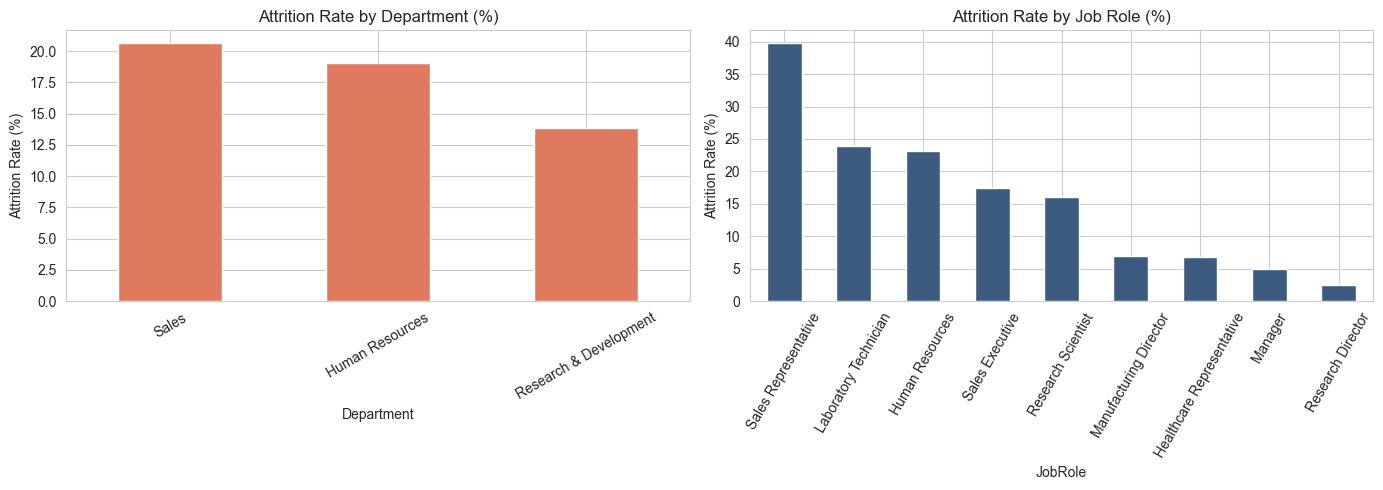

In [9]:
dept_attrition = df.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100
role_attrition = df.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_attrition.plot(kind="bar", ax=axes[0], color="#E07A5F")
axes[0].set_title("Attrition Rate by Department (%)")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

role_attrition.plot(kind="bar", ax=axes[1], color="#3D5A80")
axes[1].set_title("Attrition Rate by Job Role (%)")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig4_attrition_by_dept_role.png"), dpi=150)
plt.show()

## 5b. Workforce Composition (Department Mix)
**What:** A donut chart showing what share of the total workforce sits in
each department.
**Why:** Gives quick context for the bar charts above - e.g. if R&D is 65%
of the company, we'd expect it to dominate raw attrition *counts* even at
an *average* rate, so it helps to see headcount share alongside rate.

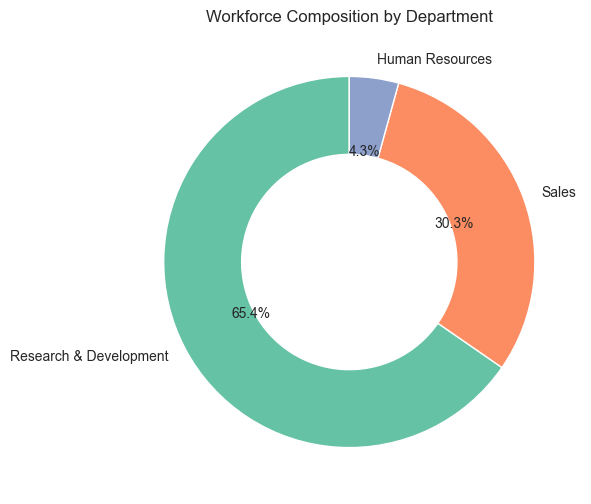

In [10]:
dept_counts = df["Department"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    dept_counts.values, labels=dept_counts.index, autopct="%1.1f%%",
    colors=sns.color_palette("Set2", len(dept_counts)), startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
plt.title("Workforce Composition by Department")
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig1b_department_mix_donut.png"), dpi=150)
plt.show()

## 6. Feature Engineering - Career-Progression Ratios
**What:** Create four new columns that express each employee's career
"health" as a ratio, normalised by their tenure:
- `Promotion_Gap_Ratio` = YearsSinceLastPromotion / YearsAtCompany
- `Role_Stagnation_Index` = YearsInCurrentRole / YearsAtCompany
- `Training_Intensity_Score` = TrainingTimesLastYear / YearsAtCompany
- `Manager_Stability_Indicator` = YearsWithCurrManager / YearsAtCompany

**Why:** A raw number like "3 years since last promotion" means very
different things for a 4-year employee (75% of their tenure without a
promotion - a red flag) versus a 20-year employee (15% of their tenure -
completely normal). Dividing by `YearsAtCompany` puts every employee on the
same comparable 0-1 scale, regardless of how long they've been at the
company.

**Guard against divide-by-zero:** `np.where(YearsAtCompany == 0, 0, ...)`
assigns a ratio of 0 to brand-new joiners, who by definition can't have a
promotion gap yet.

**Expected result:** 4 new numeric columns, each roughly in the 0-1 range.

In [11]:
df["Promotion_Gap_Ratio"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsSinceLastPromotion"] / df["YearsAtCompany"]
)
df["Role_Stagnation_Index"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsInCurrentRole"] / df["YearsAtCompany"]
)
df["Training_Intensity_Score"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["TrainingTimesLastYear"] / df["YearsAtCompany"]
)
df["Manager_Stability_Indicator"] = np.where(
    df["YearsAtCompany"] == 0, 0,
    df["YearsWithCurrManager"] / df["YearsAtCompany"]
)

print("--- After Feature Engineering ---")
print(f"Total Columns Now: {df.shape[1]}")
new_columns = ["Promotion_Gap_Ratio", "Role_Stagnation_Index",
               "Training_Intensity_Score", "Manager_Stability_Indicator"]
df[new_columns].head()

--- After Feature Engineering ---
Total Columns Now: 35


,Promotion_Gap_Ratio,Role_Stagnation_Index,Training_Intensity_Score,Manager_Stability_Indicator
0,0.000,0.666667,0.000,0.833333
1,0.100,0.700000,0.300,0.700000
2,0.000,0.000000,0.000,0.000000
3,0.375,0.875000,0.375,0.000000
4,1.000,1.000000,1.500,1.000000


## 6b. Distribution of the New Engineered Features
**What:** Histogram + smoothed density (KDE) line for each of the four
new ratios.
**Why:** Confirms the ratios behave as expected - mostly 0–1, right-skewed
(most employees are "healthy", a smaller group shows high stagnation) -
before we trust them enough to feed into clustering and risk scoring in
Step 3.

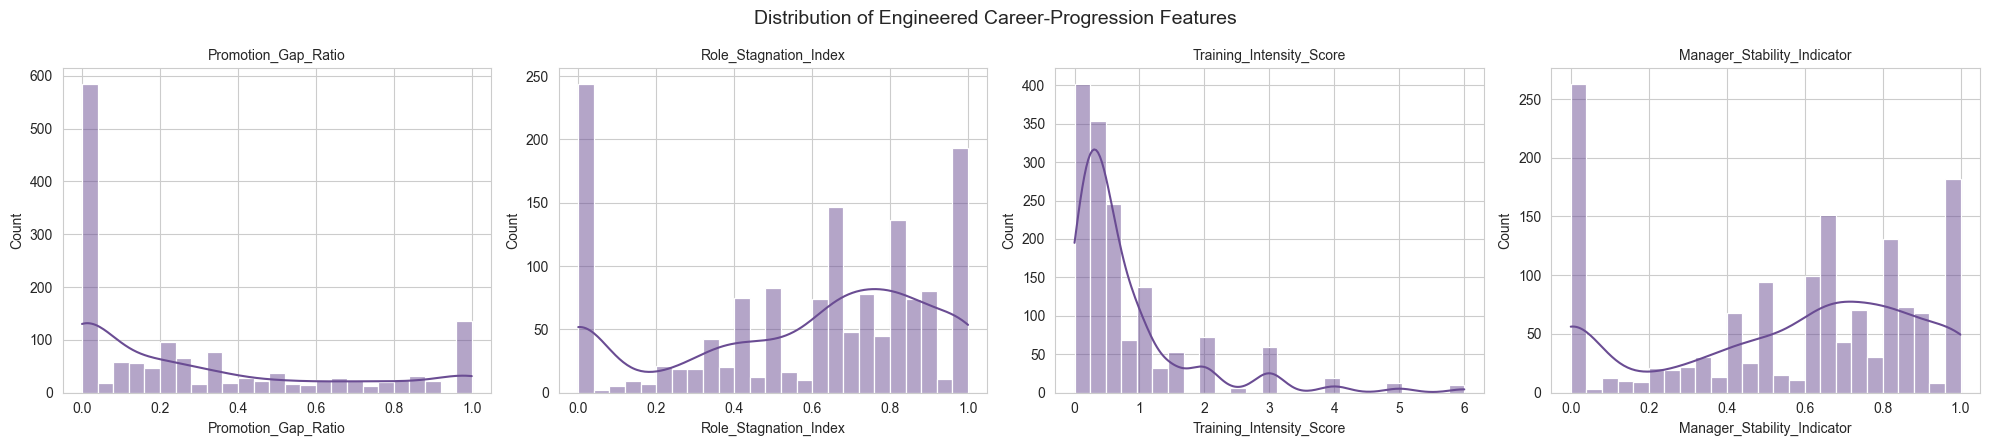

All EDA charts saved to: charts


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, new_columns):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color="#6A4C93")
    ax.set_title(col, fontsize=10)
plt.suptitle("Distribution of Engineered Career-Progression Features", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(chart_dir, "fig5_engineered_feature_distributions.png"), dpi=150)
plt.show()

print("All EDA charts saved to:", chart_dir)

## Summary
We've confirmed the dataset is clean (no missing values/duplicates),
established the attrition baseline (~16%), identified which numeric fields
correlate most with attrition, screened for outliers in tenure variables,
seen where attrition concentrates by department/role, and engineered the
four ratio features the rest of this project depends on.

**Next notebook:** `2_Feature_Engineering_Preprocessing.ipynb` - encodes
categorical fields and removes outliers to produce a clean, model-ready
dataset.